# Robustness Analysis 

## Restatement of Main Result

Our primary econometric analysis investigates the relationship between baseline graduate salary in 2018 and change in full-time employment (FTE) rates between 2018 and 2020 across Australian university study areas. **We find a negative conditional correlation between higher baseline salary and changes in FTE during the COVID-19 period.**

This is a **descriptive** analysis, which investigates conditional correlations, not a causal claim.

## Robustness Plan

To test the stability of our main finding, we implement several robustness checks:

- **Alternative functional form:** Use the log of salary instead of salary level.
- **Alternative samples:** Exclude salary outliers and health-related study areas.
- **Alternative inference:** All models use heteroskedasticity-robust (HC3) standard errors.
- **Influence diagnostics:** Calculate Cook’s distance to identify influential study areas.
- **Sensitivity analysis:** Perform leave-one-out (jackknife) checks to assess how much the main coefficient depends on individual observations.
- We summarize all checks side-by-side in a robustness table and discuss the influence and sensitivity results in detail.

Each check is explained, executed, and interpreted below.

In [27]:
# Packages

import pandas as pd 
import numpy as np 
import statsmodels.api as sm 
import statsmodels.formula.api as smf 

# Load clean data
df = pd.read_csv("../data/clean/final_pandemic_research_data.csv")
df.head()

,Study_Area,Salary_18,Salary_20,FTE_18,FTE_20,Salary_Diff,FTE_Diff
0,Science and mathematics,61000,64000.0,64.6,59.1,3000.0,-5.5
1,Computing and Information Systems,60000,65000.0,73.2,72.1,5000.0,-1.1
2,Engineering,65000,69500.0,83.1,83.0,4500.0,-0.1
3,Architecture and built environment,58700,64700.0,77.7,67.7,6000.0,-10.0
4,Agriculture and environmental studies,58300,61500.0,68.3,67.4,3200.0,-0.9


In [28]:
# Remove unwanted aggregate rows
df = df[~df["Study_Area"].isin(["All", "Standard deviation"])]
print(df["Study_Area"])
print(df.shape)

# Rescale salary into thousands of AUD for easier interpretation
df["Salary_18_k"] = df["Salary_18"] / 1000

0                               Science and mathematics
1                     Computing and Information Systems
2                                           Engineering
3                    Architecture and built environment
4                 Agriculture and environmental studies
5                           Health services and support
6                                              Medicine
7                                               Nursing
8                                              Pharmacy
9                                             Dentistry
10                                   Veterinary science
11                                       Rehabilitation
12                                    Teacher education
13                              Business and management
14              Humanities, culture and social sciences
15                                          Social work
16                                           Psychology
17                            Law and paralegal 

## Main Specification (Baseline)
Simple OLS: FTE change vs baseline salary, all study areas. 

In [29]:
model1 = smf.ols(
    "FTE_Diff ~ Salary_18_k", 
    data=df
).fit(cov_type="HC3")

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:               FTE_Diff   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                 -0.036
Method:                 Least Squares   F-statistic:                    0.2795
Date:                Thu, 21 May 2026   Prob (F-statistic):              0.603
Time:                        17:45:22   Log-Likelihood:                -51.040
No. Observations:                  21   AIC:                             106.1
Df Residuals:                      19   BIC:                             108.2
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.7393      5.379     -0.323      

## Robustness Check 1: Alternative Functional Form (Log of Salary)
Tests sensitivity to skew/outliers in salary.

In [30]:
df["log_salary"] = np.log(df["Salary_18"])
model2 = smf.ols(
    "FTE_Diff ~ log_salary",
    data=df
).fit(cov_type="HC3")

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:               FTE_Diff   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                 -0.040
Method:                 Least Squares   F-statistic:                    0.1810
Date:                Thu, 21 May 2026   Prob (F-statistic):              0.675
Time:                        17:45:22   Log-Likelihood:                -51.086
No. Observations:                  21   AIC:                             106.2
Df Residuals:                      19   BIC:                             108.3
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.6545     63.964      0.354      0.7

## Interpretation: Robustness Check 1 (Log Salary Specification)

This robustness check replaces baseline salary with the logarithm of salary to reduce the influence of extremely high-income study areas and possible skewness in salary values. 

When using the logarithm of baseline salary, the sign of the coefficient remains negative and the result is statistically insignificant (p > 0.05). 

This result indicates that the negative relationship between baseline salary and changes in full-time employment is not very stable across alternative specifications. Therefore, the main descriptive finding should be interpreted cautiously.  

## Robustness Check 2: Exclude Salary Outliers 
Drops study areas with extreme salary values, based on IQR (Turkey rule).

In [46]:
q1 = df["Salary_18"].quantile(0.25)
q3 = df["Salary_18"].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr 

df_no_outliers = df[
    (df["Salary_18"] >= lower) &
    (df["Salary_18"] <= upper)
]

df_no_outliers = df_no_outliers.copy()
df_no_outliers["Salary_18_k"] = df_no_outliers["Salary_18"] / 1000

print(df_no_outliers[["Study_Area", "Salary_18"]]) 
print(df_no_outliers.shape)

                                           Study_Area  Salary_18
0                             Science and mathematics      61000
1                   Computing and Information Systems      60000
2                                         Engineering      65000
3                  Architecture and built environment      58700
4               Agriculture and environmental studies      58300
5                         Health services and support      62600
7                                             Nursing      61600
10                                 Veterinary science      55000
11                                     Rehabilitation      62600
12                                  Teacher education      65500
13                            Business and management      58000
14            Humanities, culture and social sciences      58400
15                                        Social work      65600
16                                         Psychology      60000
17                       

In [32]:
model3 = smf.ols(
    "FTE_Diff ~ Salary_18_k",
    data=df_no_outliers
).fit(cov_type="HC3")

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:               FTE_Diff   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     4.310
Date:                Thu, 21 May 2026   Prob (F-statistic):             0.0555
Time:                        17:45:22   Log-Likelihood:                -39.203
No. Observations:                  17   AIC:                             82.41
Df Residuals:                      15   BIC:                             84.07
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -23.4514      9.092     -2.579      

## Interpretation: Robustness Check 2 (Excluding Salary Outliers)

This robustness check removes study areas with unusually high or low salary values using the interquartile range (IQR) method. The purpose is to test whether the main result is driven by a small number of extreme observations. 

After excluding outliers, the coefficient on baseline salary became positive and statistically significant. This differs from the earlier specifications, where the relationship was negative and statistically insignificant. 

The result suggests that the direction and strength of the relationship are sensitive to sample composition and the inclusion of observations with relatively unusual salary values.Therefore, the main descriptive finding does not appear fully stable across alternative samples and should be interpreted cautiously.

## Robustness Check 3: Exclude Health-related Study Areas
Health disciplines may have been affected differently by the pandemic.

In [33]:
df_non_health = df[
    ~df["Study_Area"].str.contains(
        "Health|Medicine|Nursing|Pharmacy|Dentistry|Rehabilitation",
        case=False,
        na=False
    )
]

df_non_health = df_non_health.copy()
df_non_health["Salary_18_k"] = df_non_health["Salary_18"] / 1000

print(df_non_health["Study_Area"])
print(df_non_health.shape)

0                               Science and mathematics
1                     Computing and Information Systems
2                                           Engineering
3                    Architecture and built environment
4                 Agriculture and environmental studies
10                                   Veterinary science
12                                    Teacher education
13                              Business and management
14              Humanities, culture and social sciences
15                                          Social work
16                                           Psychology
17                            Law and paralegal studies
18                                        Creative arts
19                                       Communications
20    Tourism, Hospitality, Personal Services, Sport...
Name: Study_Area, dtype: str
(15, 9)


In [34]:
model4 = smf.ols(
    "FTE_Diff ~ Salary_18_k",
    data=df_non_health
).fit(cov_type="HC3")

print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:               FTE_Diff   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     4.716
Date:                Thu, 21 May 2026   Prob (F-statistic):             0.0490
Time:                        17:45:22   Log-Likelihood:                -34.749
No. Observations:                  15   AIC:                             73.50
Df Residuals:                      13   BIC:                             74.91
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -22.8128      8.189     -2.786      

## Interpretation: Robustness Check 3 (Excluding Health-Related Disciplines)

This robustness check excludes health-related study areas because the COVID-19 pandemic may have affected healthcare sectors differently from other industries. 

After removing health-related disciplines, the coefficient on baseline salary became positive and statistically significant. This suggests that among non-health study areas, higher baseline salaries were associated with smaller declines in full-time employment during the pandemic period.

The result differs from the baseline specification, indicating that the overall relationship is sensitive to the inclusion of health-related disciplines. Therefore, the maindescriptive finding should be interpreted carefully, as different subsamples produce different conclusions. 

## Robustness Table (Stargazer, Side-by-side Results)
Install the package below:

In [35]:
import sys
!{sys.executable} -m pip install stargazer


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [45]:
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

robustness_table = Stargazer([model1, model2, model3, model4])

robustness_table.title("Robustness Analysis")
robustness_table.custom_columns(
    ["Baseline", "Log Salary", "No Outliers", "Non-Health Sample"],
    [1, 1, 1, 1]
)

robustness_table.show_model_numbers(False)

robustness_table.covariate_order([
    "Salary_18_k",
    "log_salary"
])

robustness_table.rename_covariates({
    "Salary_18_k": "Baseline Salary (2018, $000 AUD)",
    "log_salary": "Log Salary"
})

HTML(robustness_table.render_html())

### Notes

- Column 1 reports the baseline specification using the full cleaned sample of study areas.
- Column 2 replaces baseline salary with the logarithm of salary to test an alternative functional form.
- Column 3 excludes salary outliers using the interquartile range (IQR) method.
- Column 4 excludes health-related study areas to test whether the relationship is driven by pandemic-sensitive sectors.
- All regressions use HC3 heteroskedasticity-robust standard errors; Observations (N) is number of study areas in each specification. 

## Interpretation

The robustness checks show that the relationship between baseline salary and changes in full-time employment is sensitive to specification choice and sample composition. 

The baseline and logarithmic salary models produced negative but statistically insiginificant relationships. However, after removing salary outliers or excluding health-related disciplines, the coefficient became positive and statistically significant. 

This indicates that the estimated relationship is not stable across alternative specification. In particular, the change in sign suggests that certain observations or groups may be influencing the baseline result.
Therefore, the main descriptive finding should be interpreted cautiously, as different modelling choices produce different conclusions. 


## Diagnosing Instability: Influence and Sensitivity Analysis

### 1. Influence Diagnostics: Cook's Distance plot

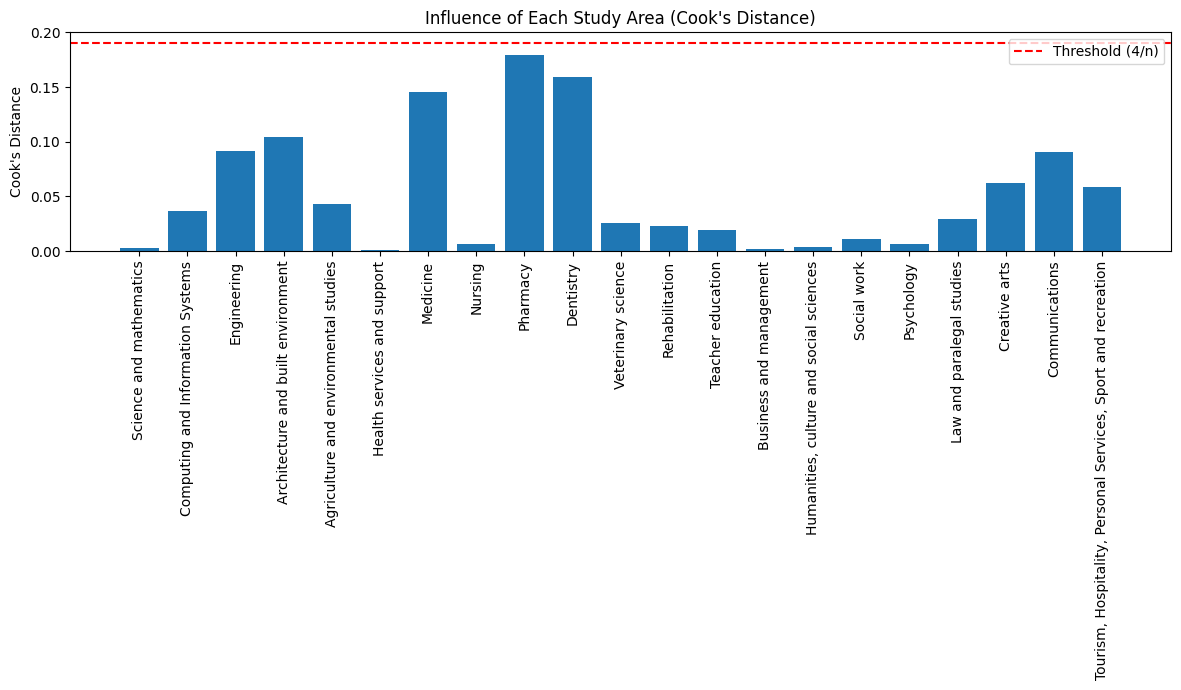

In [44]:
import matplotlib.pyplot as plt

influence = model1.get_influence()
cooks = influence.cooks_distance[0]

plt.figure(figsize=(12,7))
plt.bar(df['Study_Area'], cooks)
plt.xticks(rotation=90)
plt.ylabel("Cook's Distance")
plt.title("Influence of Each Study Area (Cook's Distance)")
plt.axhline(4/len(df), color='red', linestyle='--', label='Threshold (4/n)')
plt.legend()
plt.tight_layout()
plt.show()

### Influence Diagnostics
The plot above shows the Cook's distance for each study area in the baseline regression. The dashed line marks a common "rule-of-thumb" threshold for influential points 4/n, where n is the number of observations. 

**Observation:**
- No study area formally exceeds the common Cook’s Distance rule-of-thumb threshold (4/n).
- However, Pharmacy has the highest Cook’s Distance and lies close to the threshold.
- Dentistry and Medicine also show relatively elevated Cook’s Distance values compared with most other study areas.

**Interpretation:**
- This suggests that while no single observation can be classified as an extreme outlier by this metric, several study areas exert relatively stronger influence on the regression estimates.
- Cook’s Distance alone does not fully explain the instability, which is why the leave-one-out sensitivity analysis is also important.

### 2. Leave-one-out sensitivity

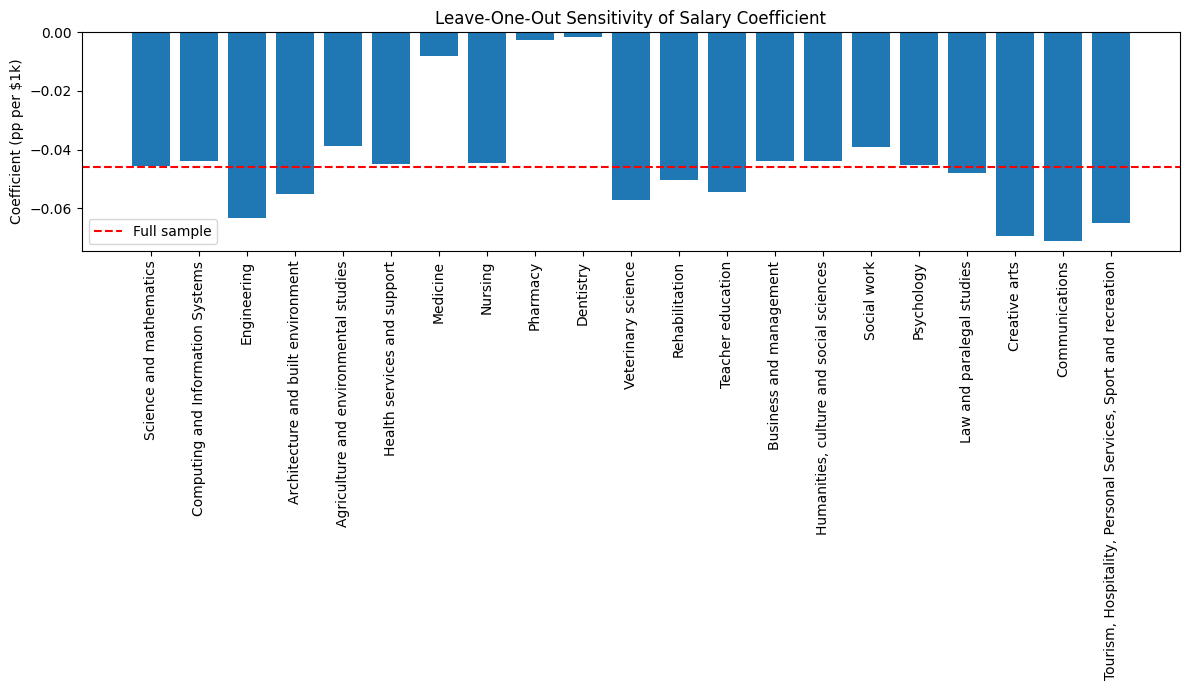

In [41]:
coefs = []
for i in range(len(df)):
    temp = df.drop(i)
    m = smf.ols("FTE_Diff ~ Salary_18_k", data=temp).fit(cov_type="HC3")
    coefs.append(m.params['Salary_18_k']) 

plt.figure(figsize=(12,7))
plt.bar(df['Study_Area'], coefs)
plt.xticks(rotation=90)
plt.ylabel("Coefficient (pp per $1k)")
plt.title("Leave-One-Out Sensitivity of Salary Coefficient")
plt.axhline(model1.params['Salary_18_k'], color='r', linestyle='--', label='Full sample')
plt.legend()
plt.tight_layout()
plt.show()

### Leave-One-Out Sensitivity 

The bar plot above shows how the estimated coefficient on baseline salary changes when each study area is excluded one at a time.

The results show that removing certain observations meaningfully changes the estimated coefficient relative to the full-sample result (shown by the red dashed line).

Interpretation:
- The regression results are sensitive to the exclusion of several individual study areas.
- Some health-related disciplines, particularly Pharmacy, Dentistry, and Medicine, noticeably shift the coefficient when excluded.
- However, several non-health study areas also produce meaningful changes in the estimate.

This suggests that the instability is not driven by one single observation or one specific sector. Instead, the combination of a small sample size and sensitivity to multiple observations makes the baseline regression fragile.

Conclusion:
The leave-one-out analysis confirms that the baseline relationship is not stable and depends on the composition of the sample.

### 3. Combine study area, Cook's distance, and leave-one-out coefficient

In [39]:
import pandas as pd

most_influential = pd.DataFrame({
    'Study_Area': df['Study_Area'],
    'Salary_18': df['Salary_18'],
    'FTE_Diff': df['FTE_Diff'],
    'Cooks_Distance': cooks,
    'LeaveOneOut_Coef': coefs,
})

# Show the top 5 by Cook's Distance
top_influential = most_influential.sort_values('Cooks_Distance', ascending=False).head(5).reset_index(drop=True)
display(top_influential)

,Study_Area,Salary_18,FTE_Diff,Cooks_Distance,LeaveOneOut_Coef
0,Pharmacy,47000,-0.8,0.179217,-0.002734
1,Dentistry,83700,-6.8,0.158814,-0.001708
2,Medicine,73000,-8.2,0.145168,-0.008048
3,Architecture and built environment,58700,-10.0,0.104380,-0.055277
4,Engineering,65000,-0.1,0.091788,-0.063405


### Most Influential Study Areas: Summary Table

The table above lists the five study areas with the highest Cook’s Distance, along with the regression coefficient for baseline salary when each study area is excluded in turn (leave-one-out).

**Interpretation:**

- "Pharmacy" has the highest Cook’s Distance, indicating that it is one of the most influential observations in the baseline regression.
- "Dentistry" and "Medicine" also show relatively high influence compared with other study areas.
- However, the leave-one-out sensitivity analysis shows that instability is not driven only by health-related disciplines. Several non-health study areas, including Engineering, Architecture and built environment, Communications, Creative Arts, and Tourism, also meaningfully change the estimated salary coefficient when excluded.

These influential observations differ substantially in both baseline salary levels and employment outcomes. For example, some high-salary study areas experienced large declines in full-time employment, while other lower-salary study areas experienced relatively smaller declines. Because these observations pull the estimated relationship in different directions, the regression becomes unstable in a small sample.

**Conclusion:**  
Even though some health-related disciplines (such as Pharmacy, Dentistry, and Medicine) show relatively high influence scores, the leave-one-out analysis shows that instability is not driven by health fields alone. Several observations across different sectors meaningfully affect the estimated coefficient.

This highlights the importance of using both formal influence diagnostics and sensitivity analysis when interpreting regression results, especially in small samples.

## Conclusion

This analysis set out to examine the relationship between baseline graduate salaries and changes in full-time employment rates across Australian university study areas during the COVID-19 period, and to assess how robust this relationship is to various empirical specifications.

### Key Findings

- **The main result is not robust.** Across different specifications: (1) log transformation of salary, (2) exclusion of outliers, and (3) exclusion of particular groups, the relationship between baseline salary and employment change varies in both strength and direction.
- **Influence and instability diagnostics help explain the fragility of the results.**
    - Cook’s Distance suggests that several study areas exert relatively stronger influence on the regression estimates, although no single observation overwhelmingly dominates the regression. Pharmacy in particular shows relatively high influence under common diagnostic rules. 
    - The leave-one-out sensitivity analysis shows that removing several individual study areas, including both health-related and non-health disciplines, meaningfully changes the estimated coefficient.
    - The small number of study areas (N = 21) amplifies the influence of individual observations and makes the results highly sensitive to sample composition.
    - Because influential observations display very different combinations of salary levels and employment outcomes, they pull the estimated regression relationship in different directions, making the baseline result unstable. 

### Implications

- **The observed relationship should be interpreted very cautiously:**  
  It is unstable and seems highly dependent on the inclusion or exclusion of particular study areas. This suggests the finding is not generalisable beyond this small sample, and any policy or practical inferences risk being misleading.
- **Influential study areas deserve further scrutiny:**  
  Before drawing strong conclusions, it is important to understand why certain fields, especially Pharmacy, Architecture and built environment, and Engineering are influential, and whether this reflects real structural differences, data limitations, or other underlying factors.
- **Rigorous diagnostic tools are essential:**  
  Influence measures and leave-one-out analyses provide valuable insight beyond standard robustness checks and help explain inconsistencies in regression results.

### Final Note

**Overall, this analysis highlights the importance of careful robustness and influence diagnostics when working with small cross-sectional datasets.** Future work could expand the dataset, aggregate fields differently, or include additional explanatory variables to better understand the sources of instability.
